In [1]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import copy

c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep.parquet")
Labled_theses_df = pd.read_csv('wahlomaten_thesen_positionen.csv')

In [3]:
lable_colums_list = Labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [4]:
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These'].tolist()
predicted_theses_df = copy.deepcopy(Labled_theses_df)

all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')
all_party_textes_df = all_party_textes_df.dropna()

In [5]:
all_party_textes_df

,Party,Chapter,These,Text,Text_no_stopwords,Text_lemmatized
3,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",brauchen bezahlbare energie geht unternehmen d...,brauchen bezahlbar Energie gehen Unternehmen D...
4,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,tun unternehmen wirtschaftsstandort schaffen d...,tun unternehmen wirtschaftsstandort schaffen d...
5,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,wirtschaft schnell schwung kommt müssen viele ...,Wirtschaft schnell Schwung kommen müssen viele...
6,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,beschworene erfndergeist deutschland obersten ...,Beschworener Erfndergeist Deutschland oberer P...
8,SPD,2. Wir kämpfen für Made in Germany 2.0.,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",unternehmen müssen sicher klimaneutralität wei...,Unternehmen müssen sicher Klimaneutralität wei...
...,...,...,...,...,...,...
545,Die Linke,17. Für eine gerechte Einwanderungsgesellschaf...,Niemand flieht freiwillig,Das Chaos an den europäischen Grenzen ist das ...,chaos europäischen grenzen ergebnis politikver...,Chaos europäisch Grenze Ergebnis Politikversag...
546,Die Linke,17. Für eine gerechte Einwanderungsgesellschaf...,Wir sind eine Einwanderungsgesellschaft – und ...,Die großen Herausforderungen von mehr Personal...,großen herausforderungen mehr personal gesundh...,groß Herausforderung mehr Personal Gesundheit ...
549,Die Linke,19. Medien und Kultur für eine plurale Gesells...,Kultur – vielfältig und für alle zugänglich,Der Zugang zu Kultur soll nicht vom Geldbeutel...,zugang kultur geldbeutel abhängen kunst kultur...,Zugang Kultur Geldbeutel abhäng Kunst Kultur z...
550,Die Linke,19. Medien und Kultur für eine plurale Gesells...,Sport ist kein Luxus,Sport ist für alle da. Dafür müssen die Zugang...,sport dafür müssen zugangsbedingungen verbesse...,Sport dafür müssen zugangsbedingungen verbesse...


In [6]:
# Lade das DeBERTa-Modell und den Tokenizer
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Funktion zur Berechnung der Embeddings mit DeBERTa
#def get_embedding(text):
#    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
#    with torch.no_grad():
#        outputs = model(**inputs)
#    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # Verwende den CLS-Token als Repräsentation

def get_embedding(text):
    # Tokenize sentences
    encoded_input = tokenizer(text, padding=True, truncation=True, return_tensors='pt')

    # Compute token embeddings
    with torch.no_grad():
        model_output = model(**encoded_input)

    token_embeddings = model_output[0]
    input_mask_expanded = encoded_input['attention_mask'].unsqueeze(-1).expand(token_embeddings.size()).float()

    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [7]:
text1 = all_party_textes_df['Text_lemmatized'].iloc[0]
text2 = Labled_theses_df['These'].iloc[0]

text1_embedded = get_embedding(text1)
text2_embedded = get_embedding(text2)

print(f'{text1}\n{text2}')

(cosine_similarity(X=text1_embedded.reshape(1, -1),Y=text2_embedded.reshape(1, -1), dense_output= False)[0][0])
#np.float32(0.99964106)

brauchen bezahlbar Energie gehen Unternehmen Deutschland Energie investieren sicher bezahlbar Energieversorgung erneuerbar Energien international wettbewerbsfähig Energiepreise geben Investitionssicherheit energiekosten stabil Preis Netzentgelt Stromsteuer besonders nord Osten groß Anteil Windenergie Deutschland produzieren hoch netzentgelt dringend Umstellung günstig erneuerbar energien massiv Ausbau stromnetze verbinden kosten Geld netzentgelt Strompreis aufgeschlag Herausforderung insbesondere international Wettbewerb stehend Wirtschaft verbraucherinn Verbraucher entgelt übertragungsnetz region Deutschland verbinden massiv ausbauen zunächst stabilisieren schnellstmöglich 3 Cent pro kilowattstund deckeln Netzausbau unterstützen wegen milliardenschwer Investition Netz derzeitig Belastung haushalt Unternehmen durchschnitt halbieren dauerhaft planungssicherheit schaffen industriell Investition Umstieg klimafreundlich Technologie elektroauto hinaus setzen dafür groß Kreis besonders strom

np.float32(0.08414061)

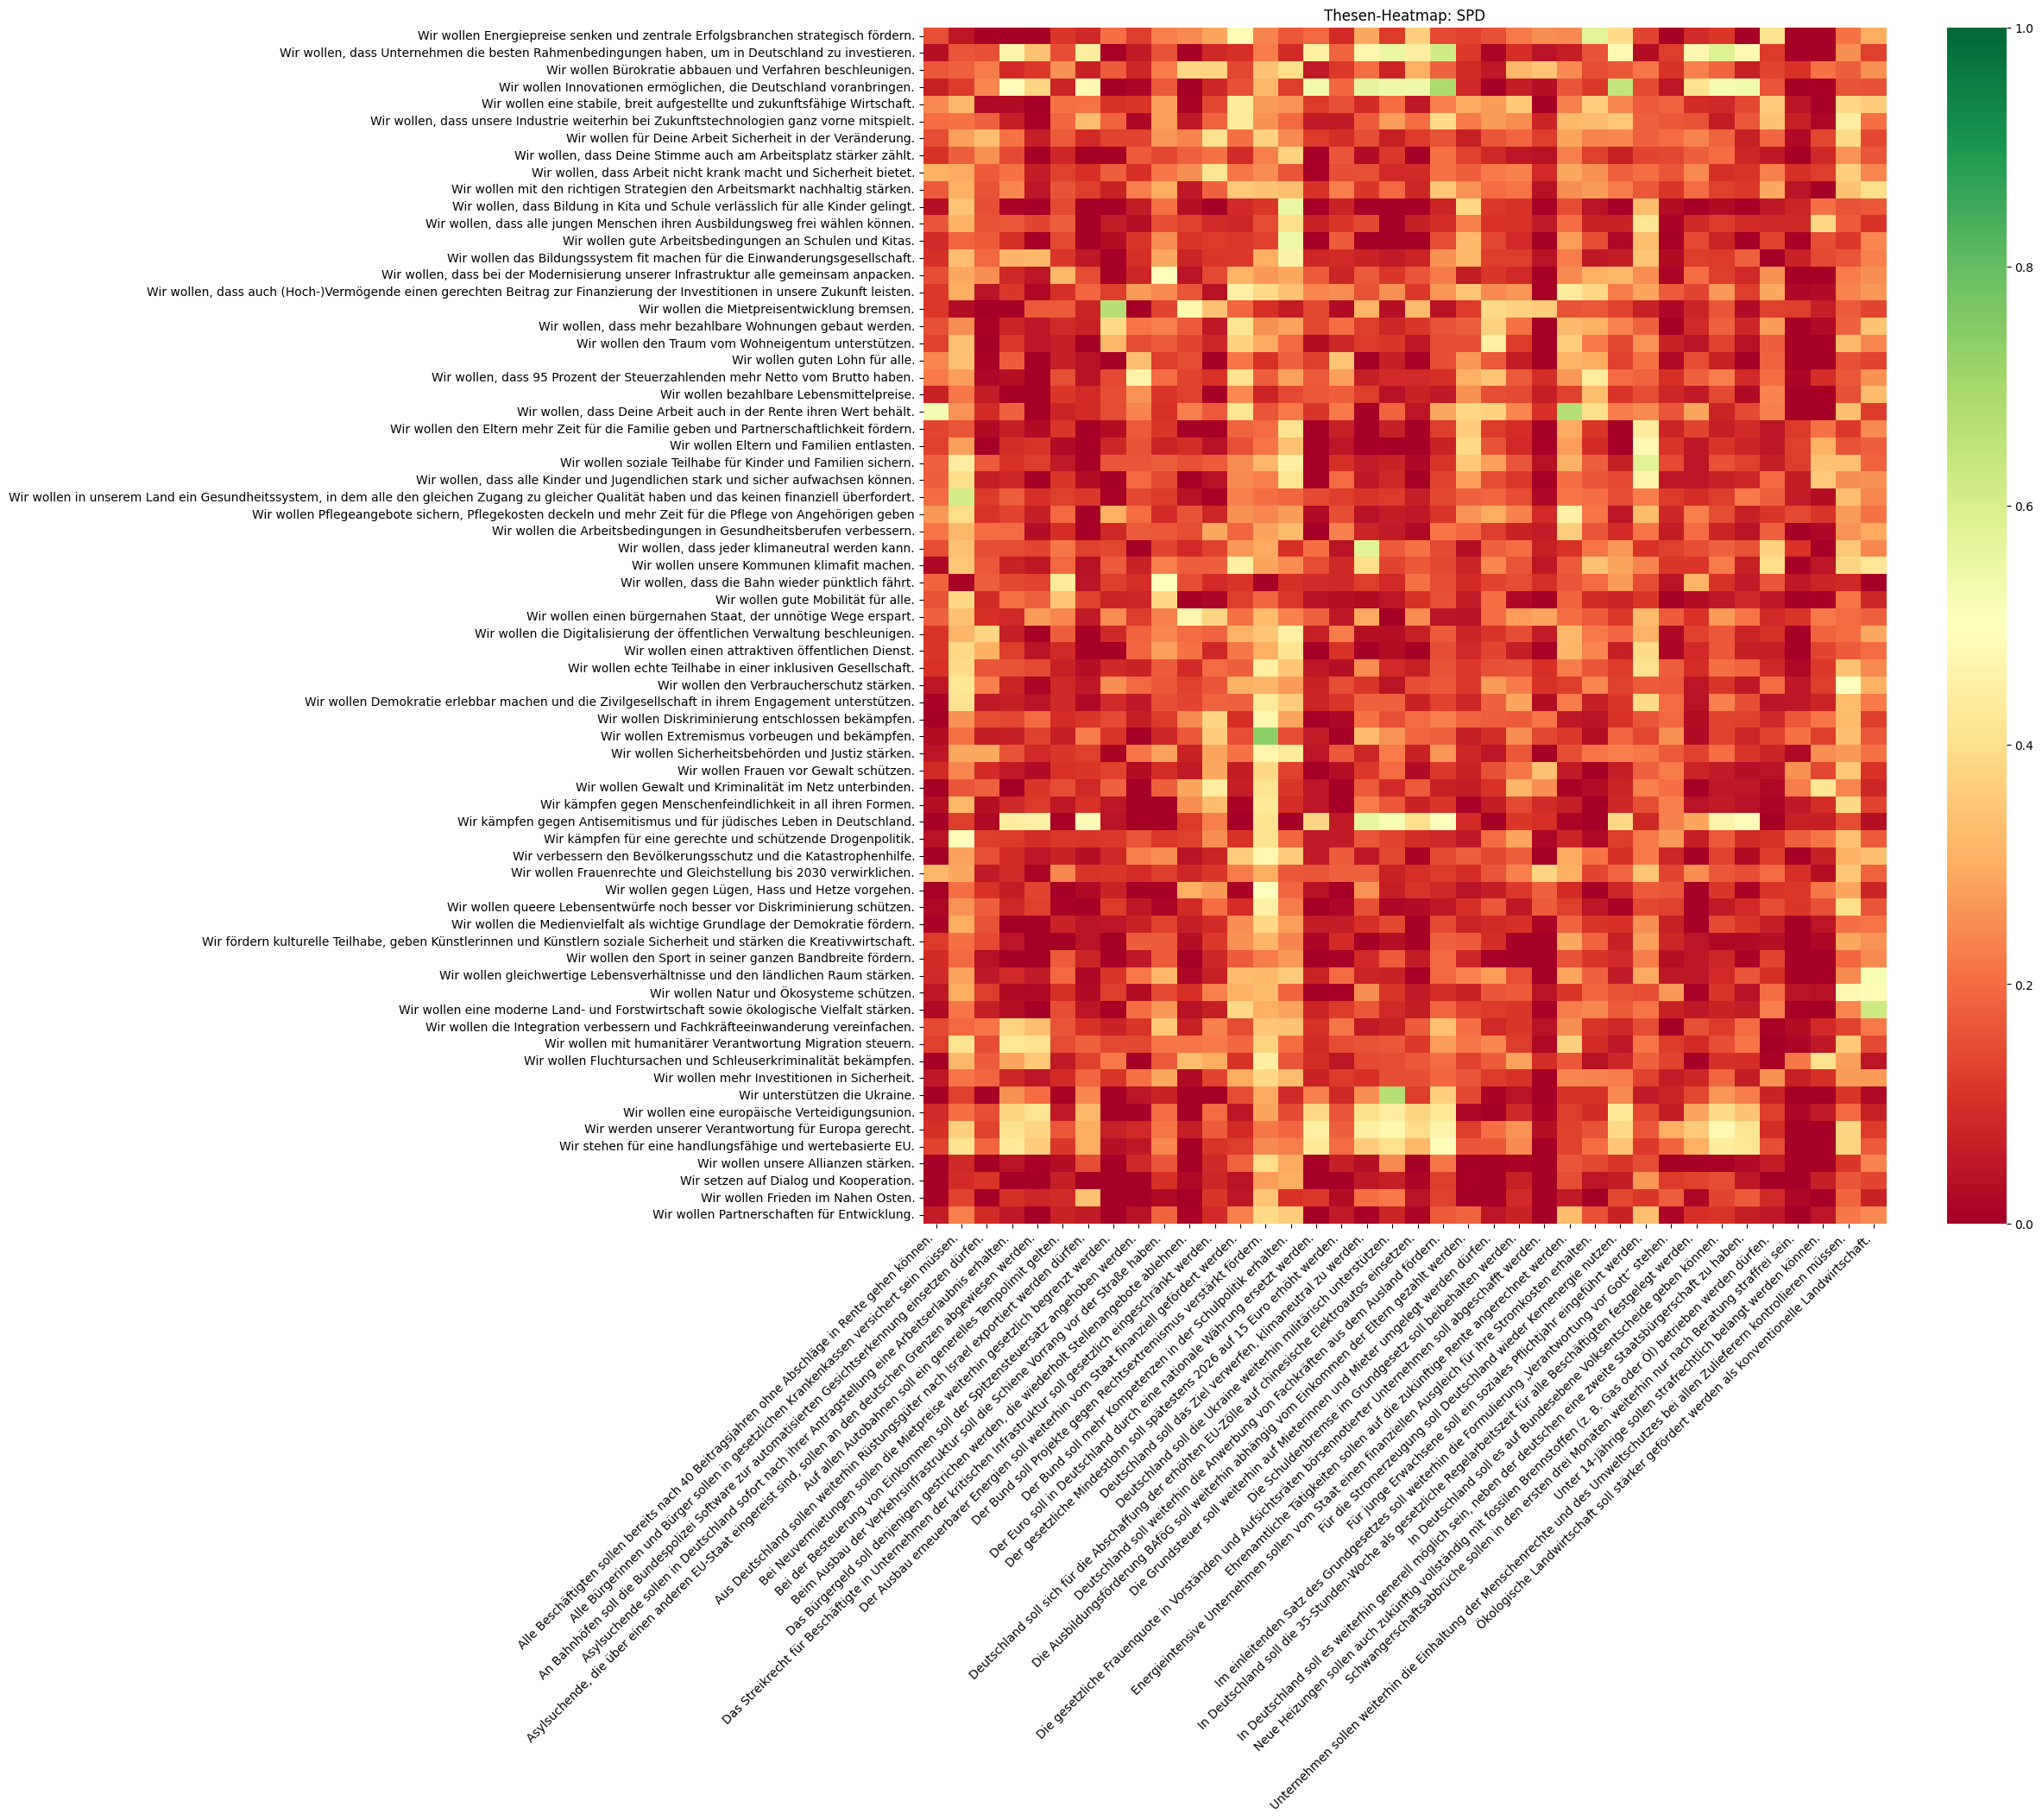

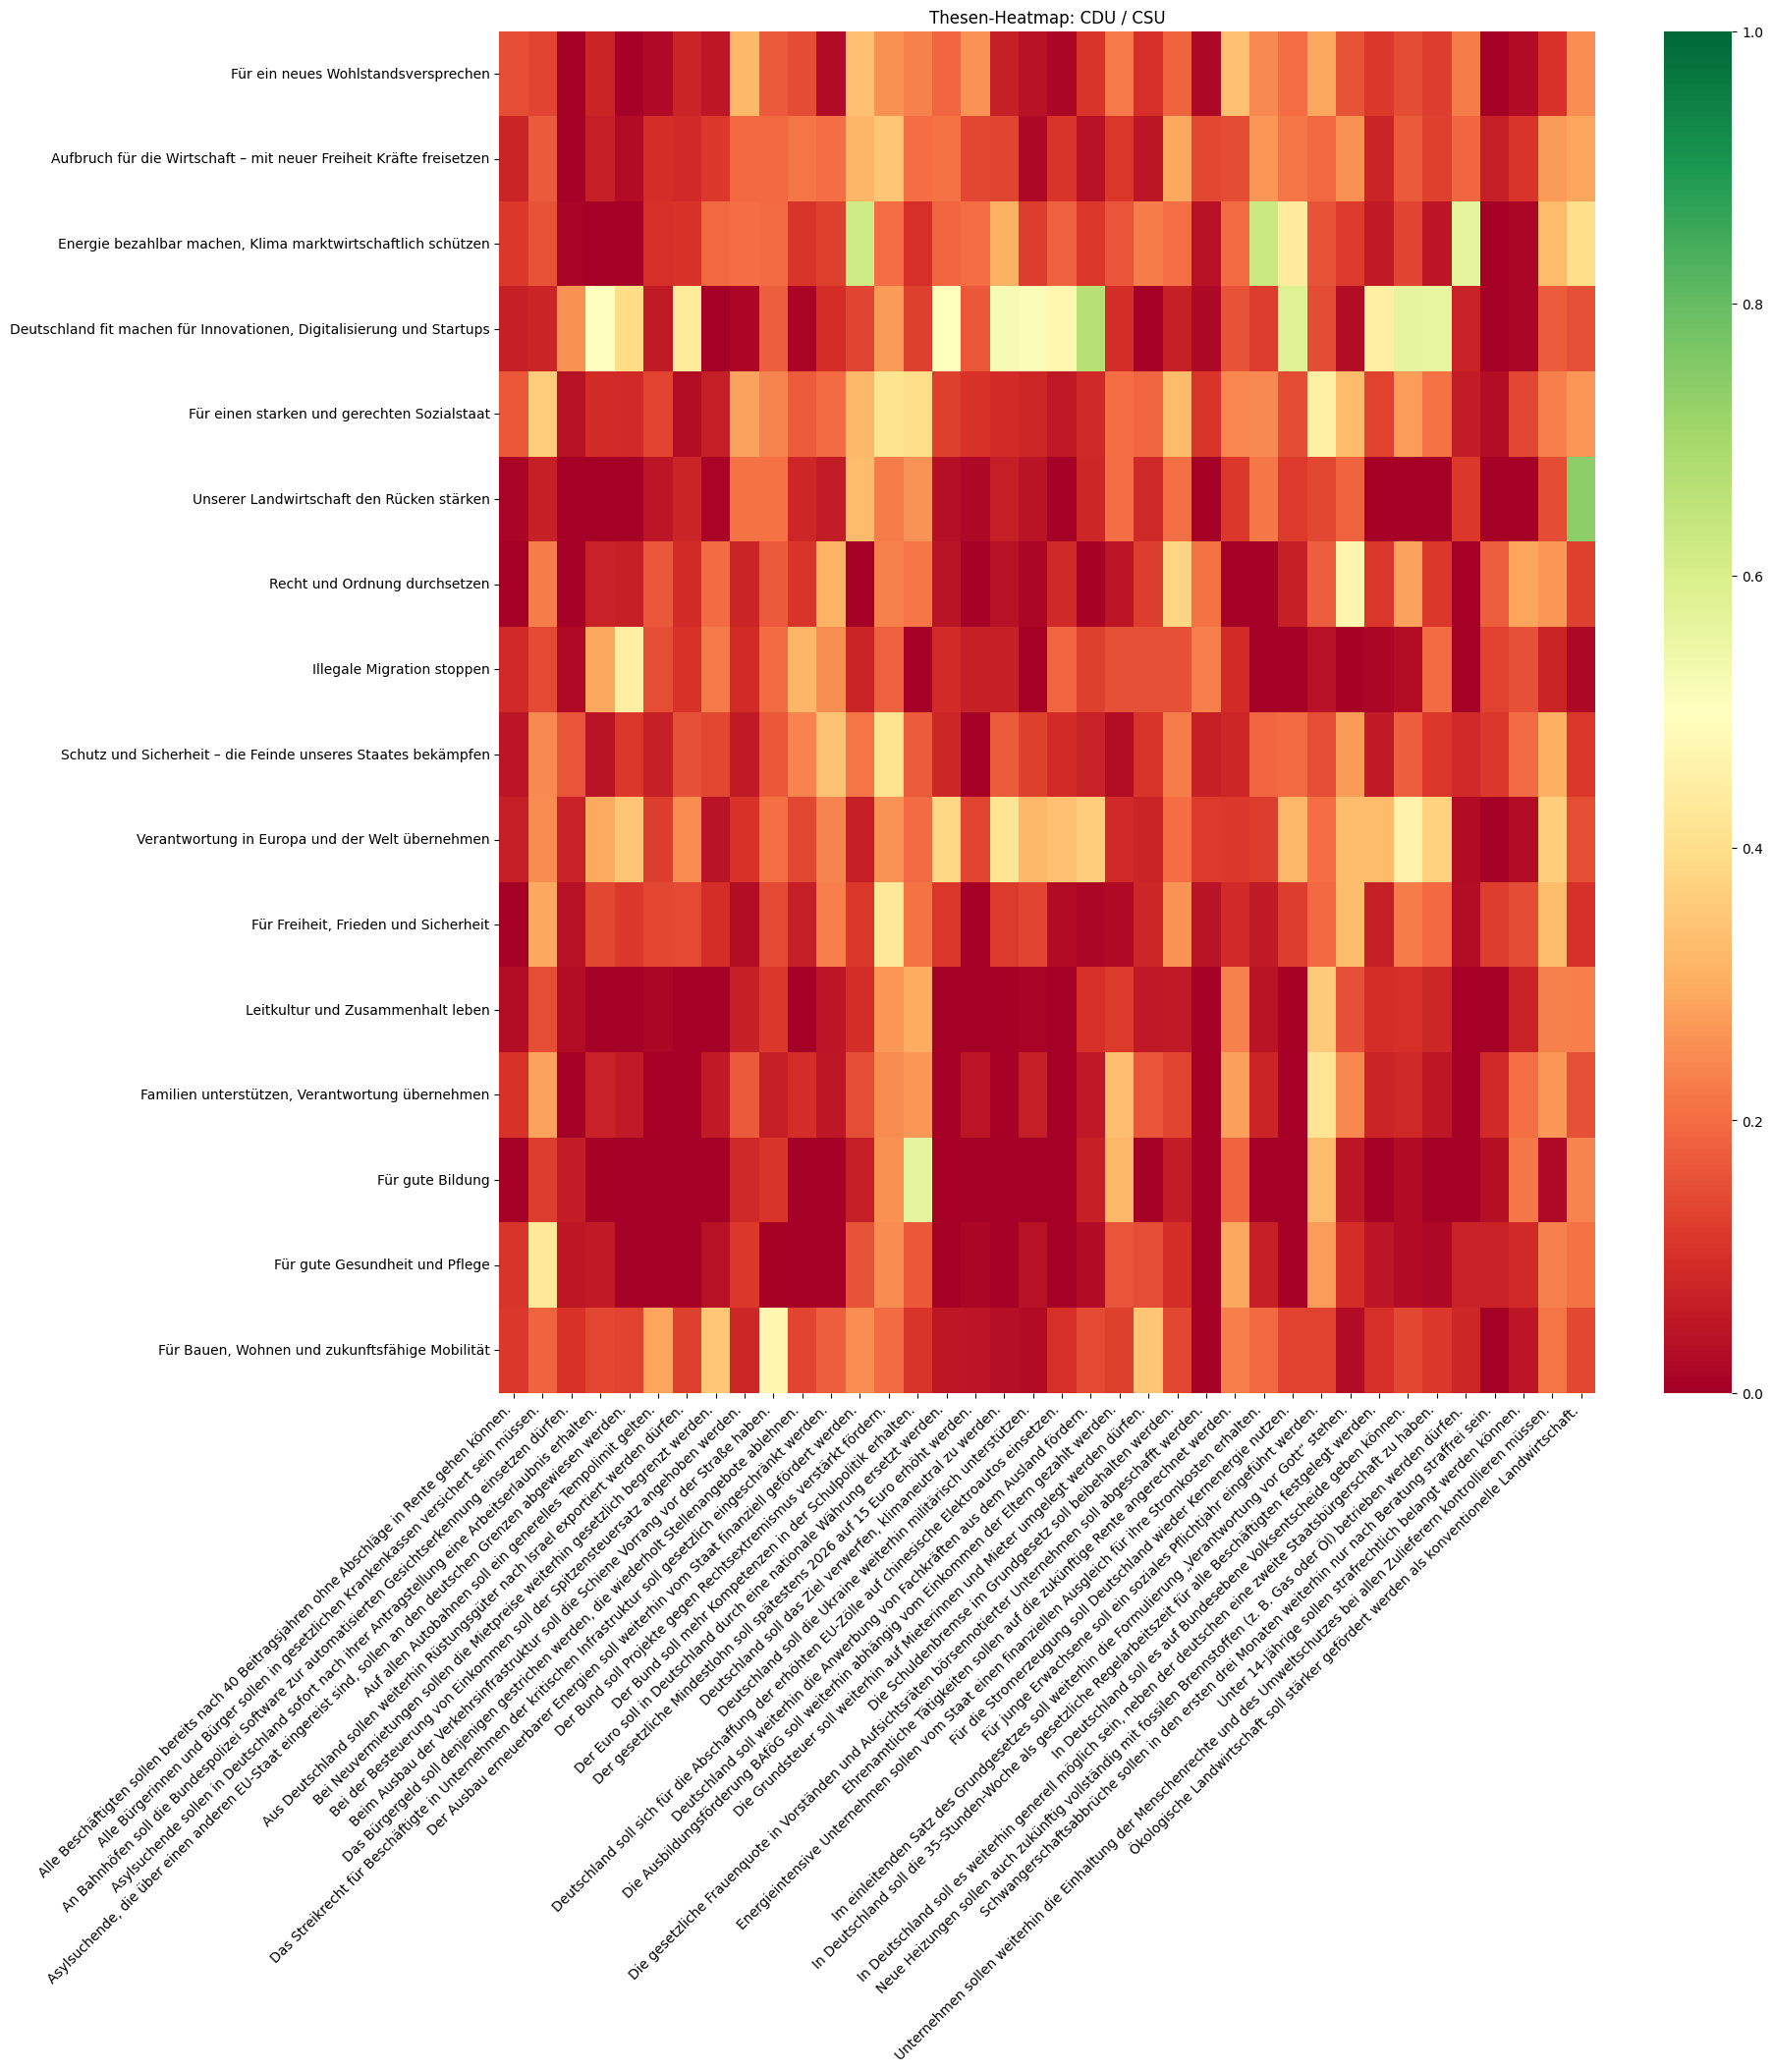

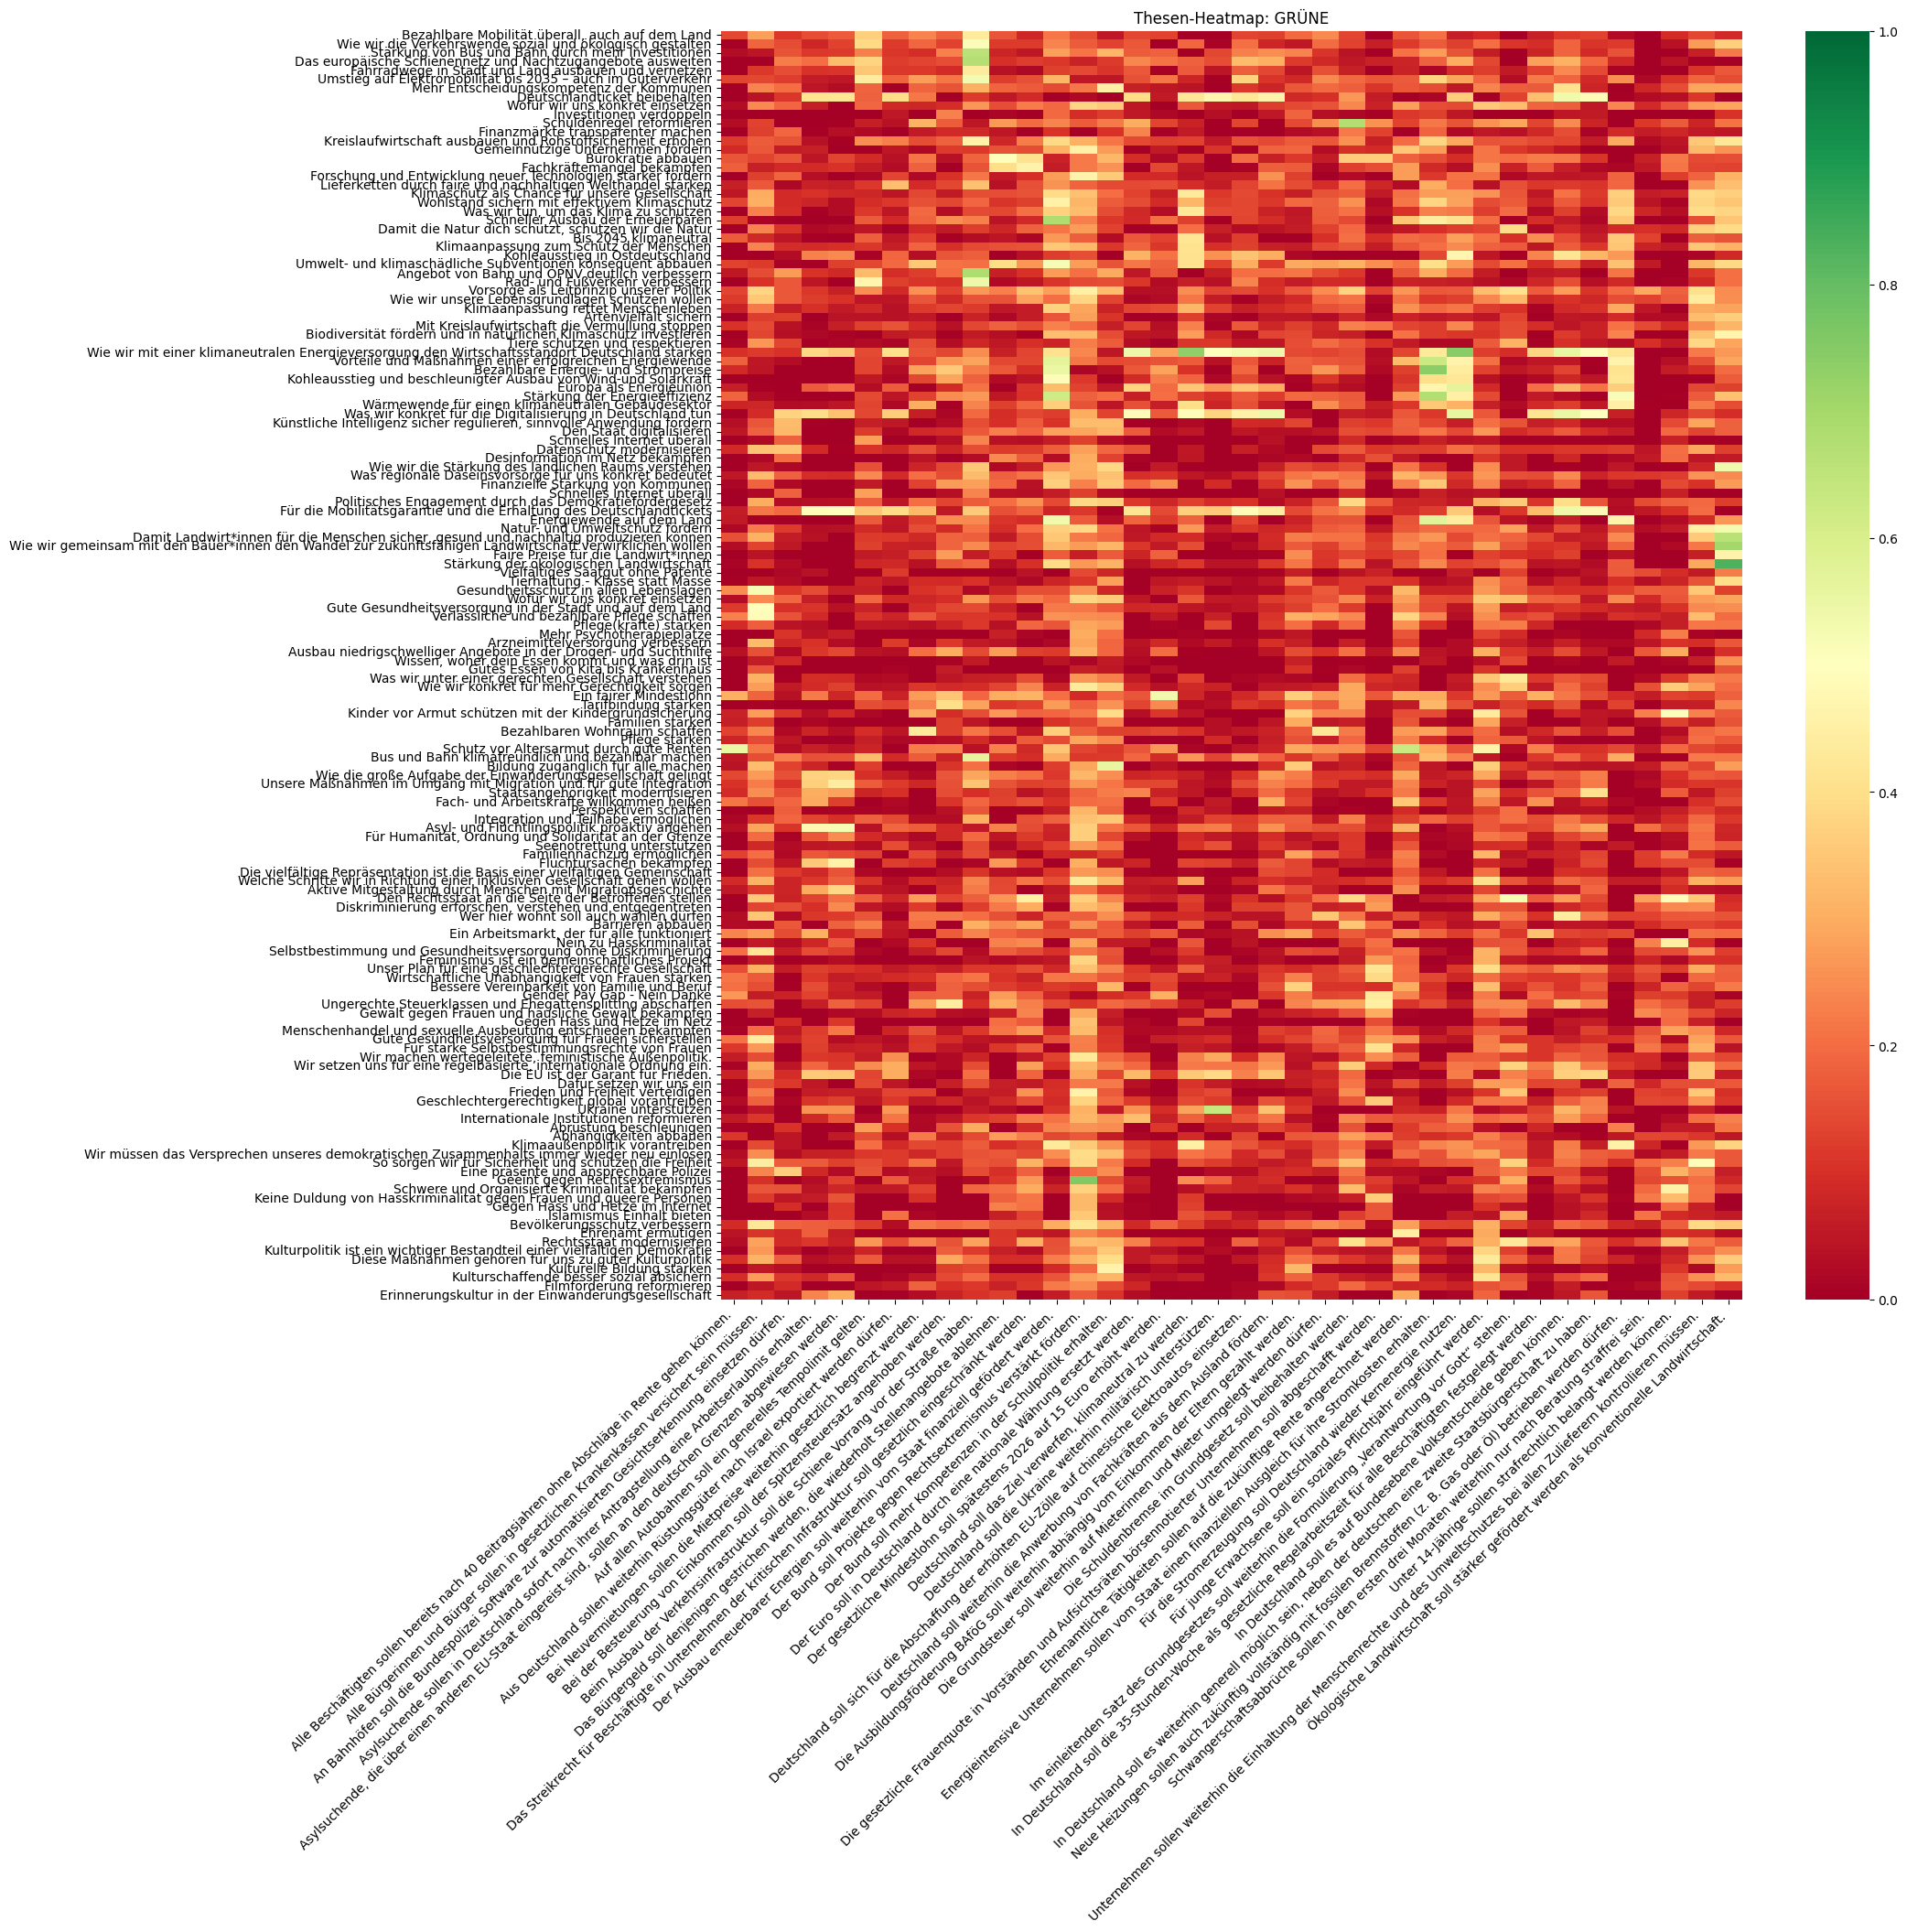

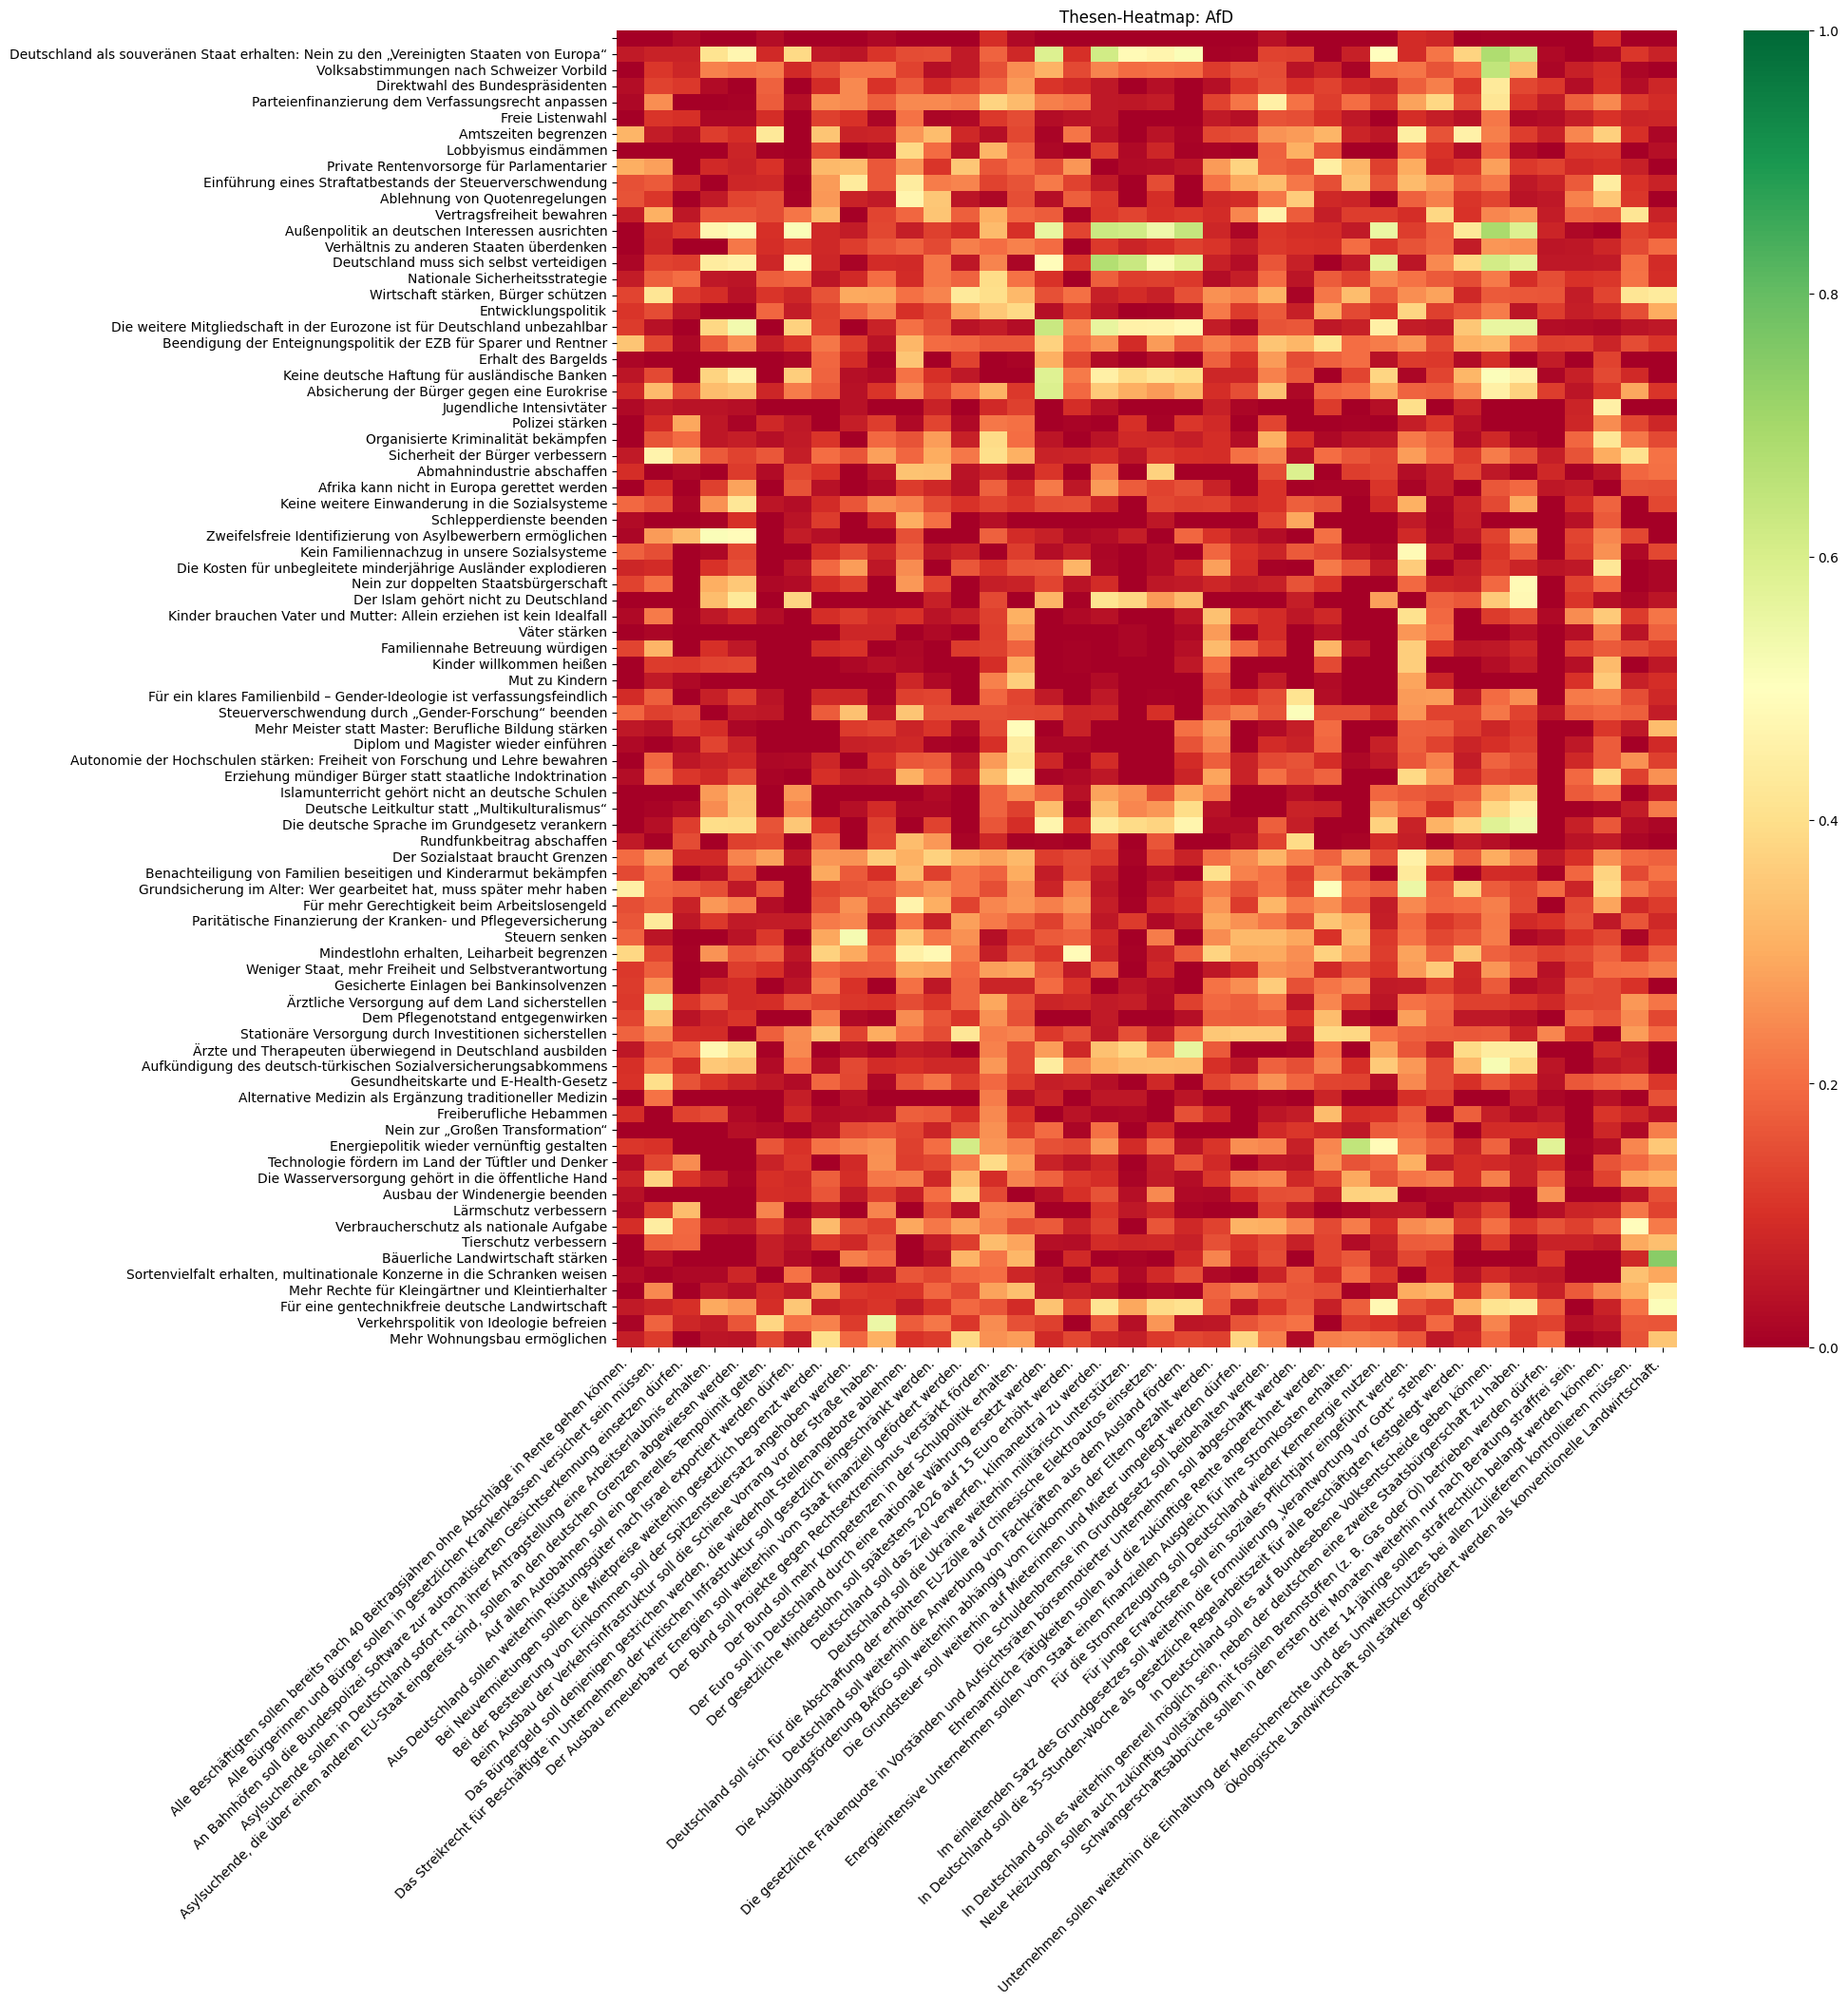

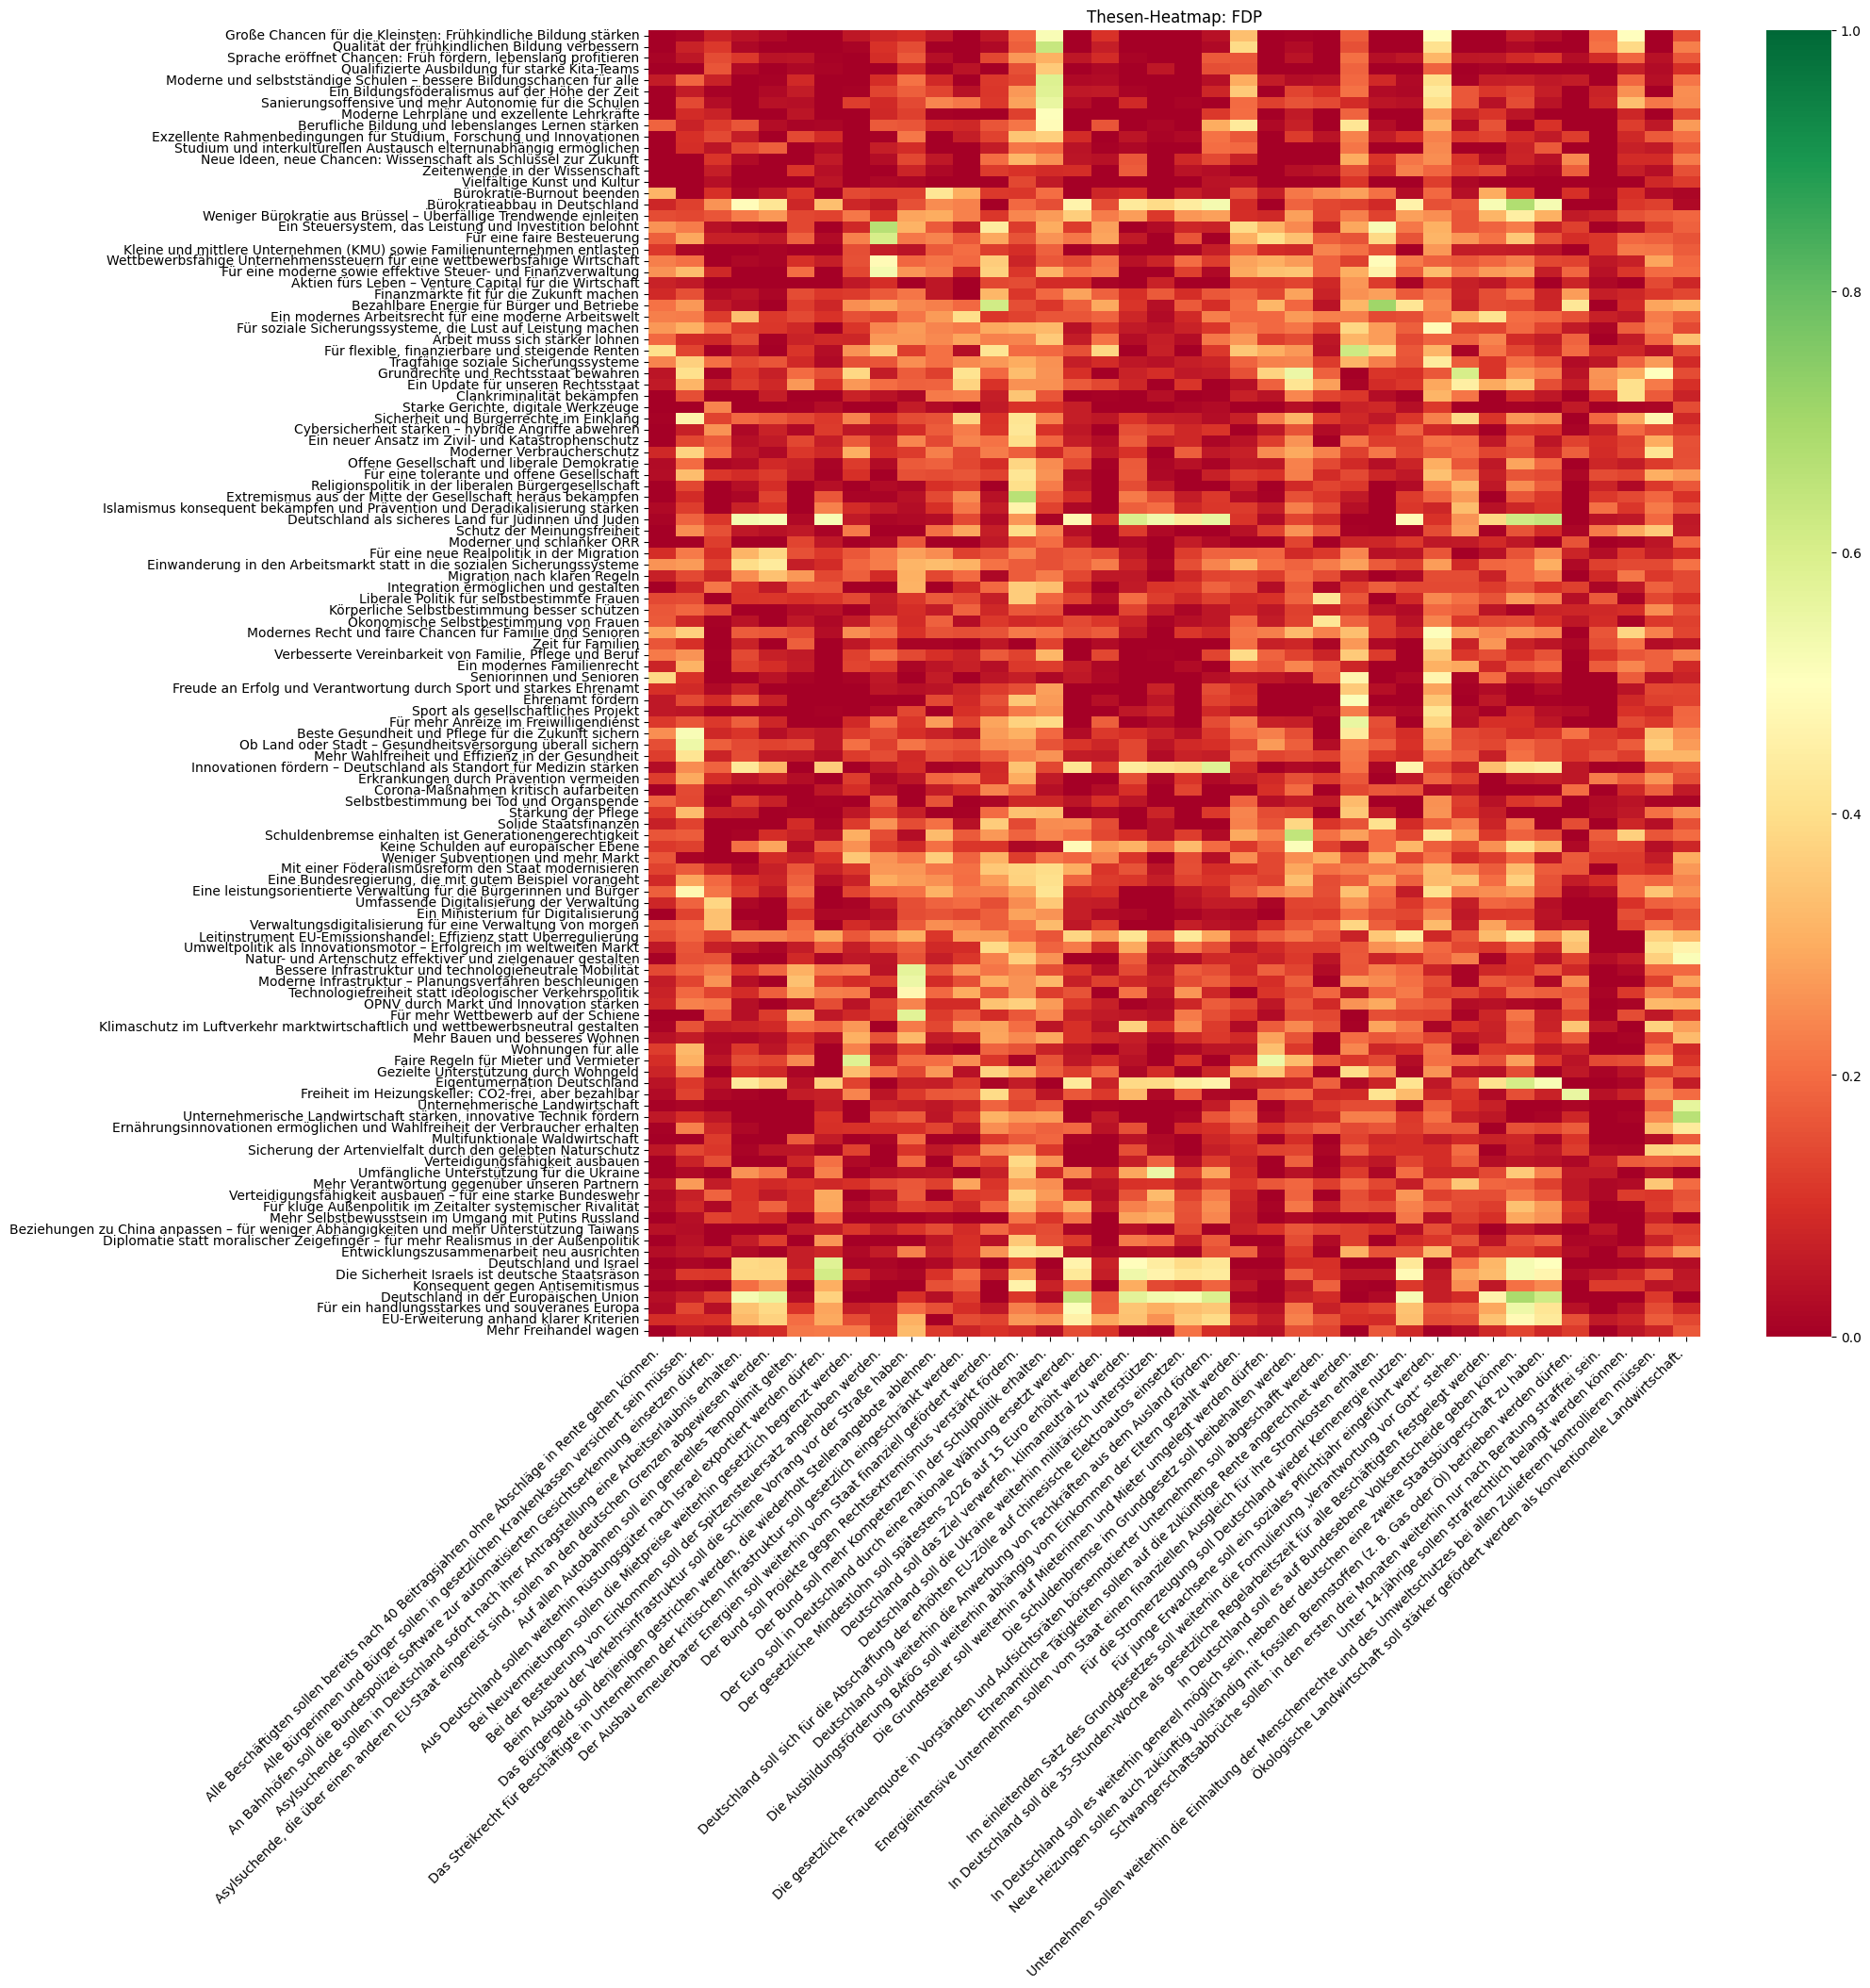

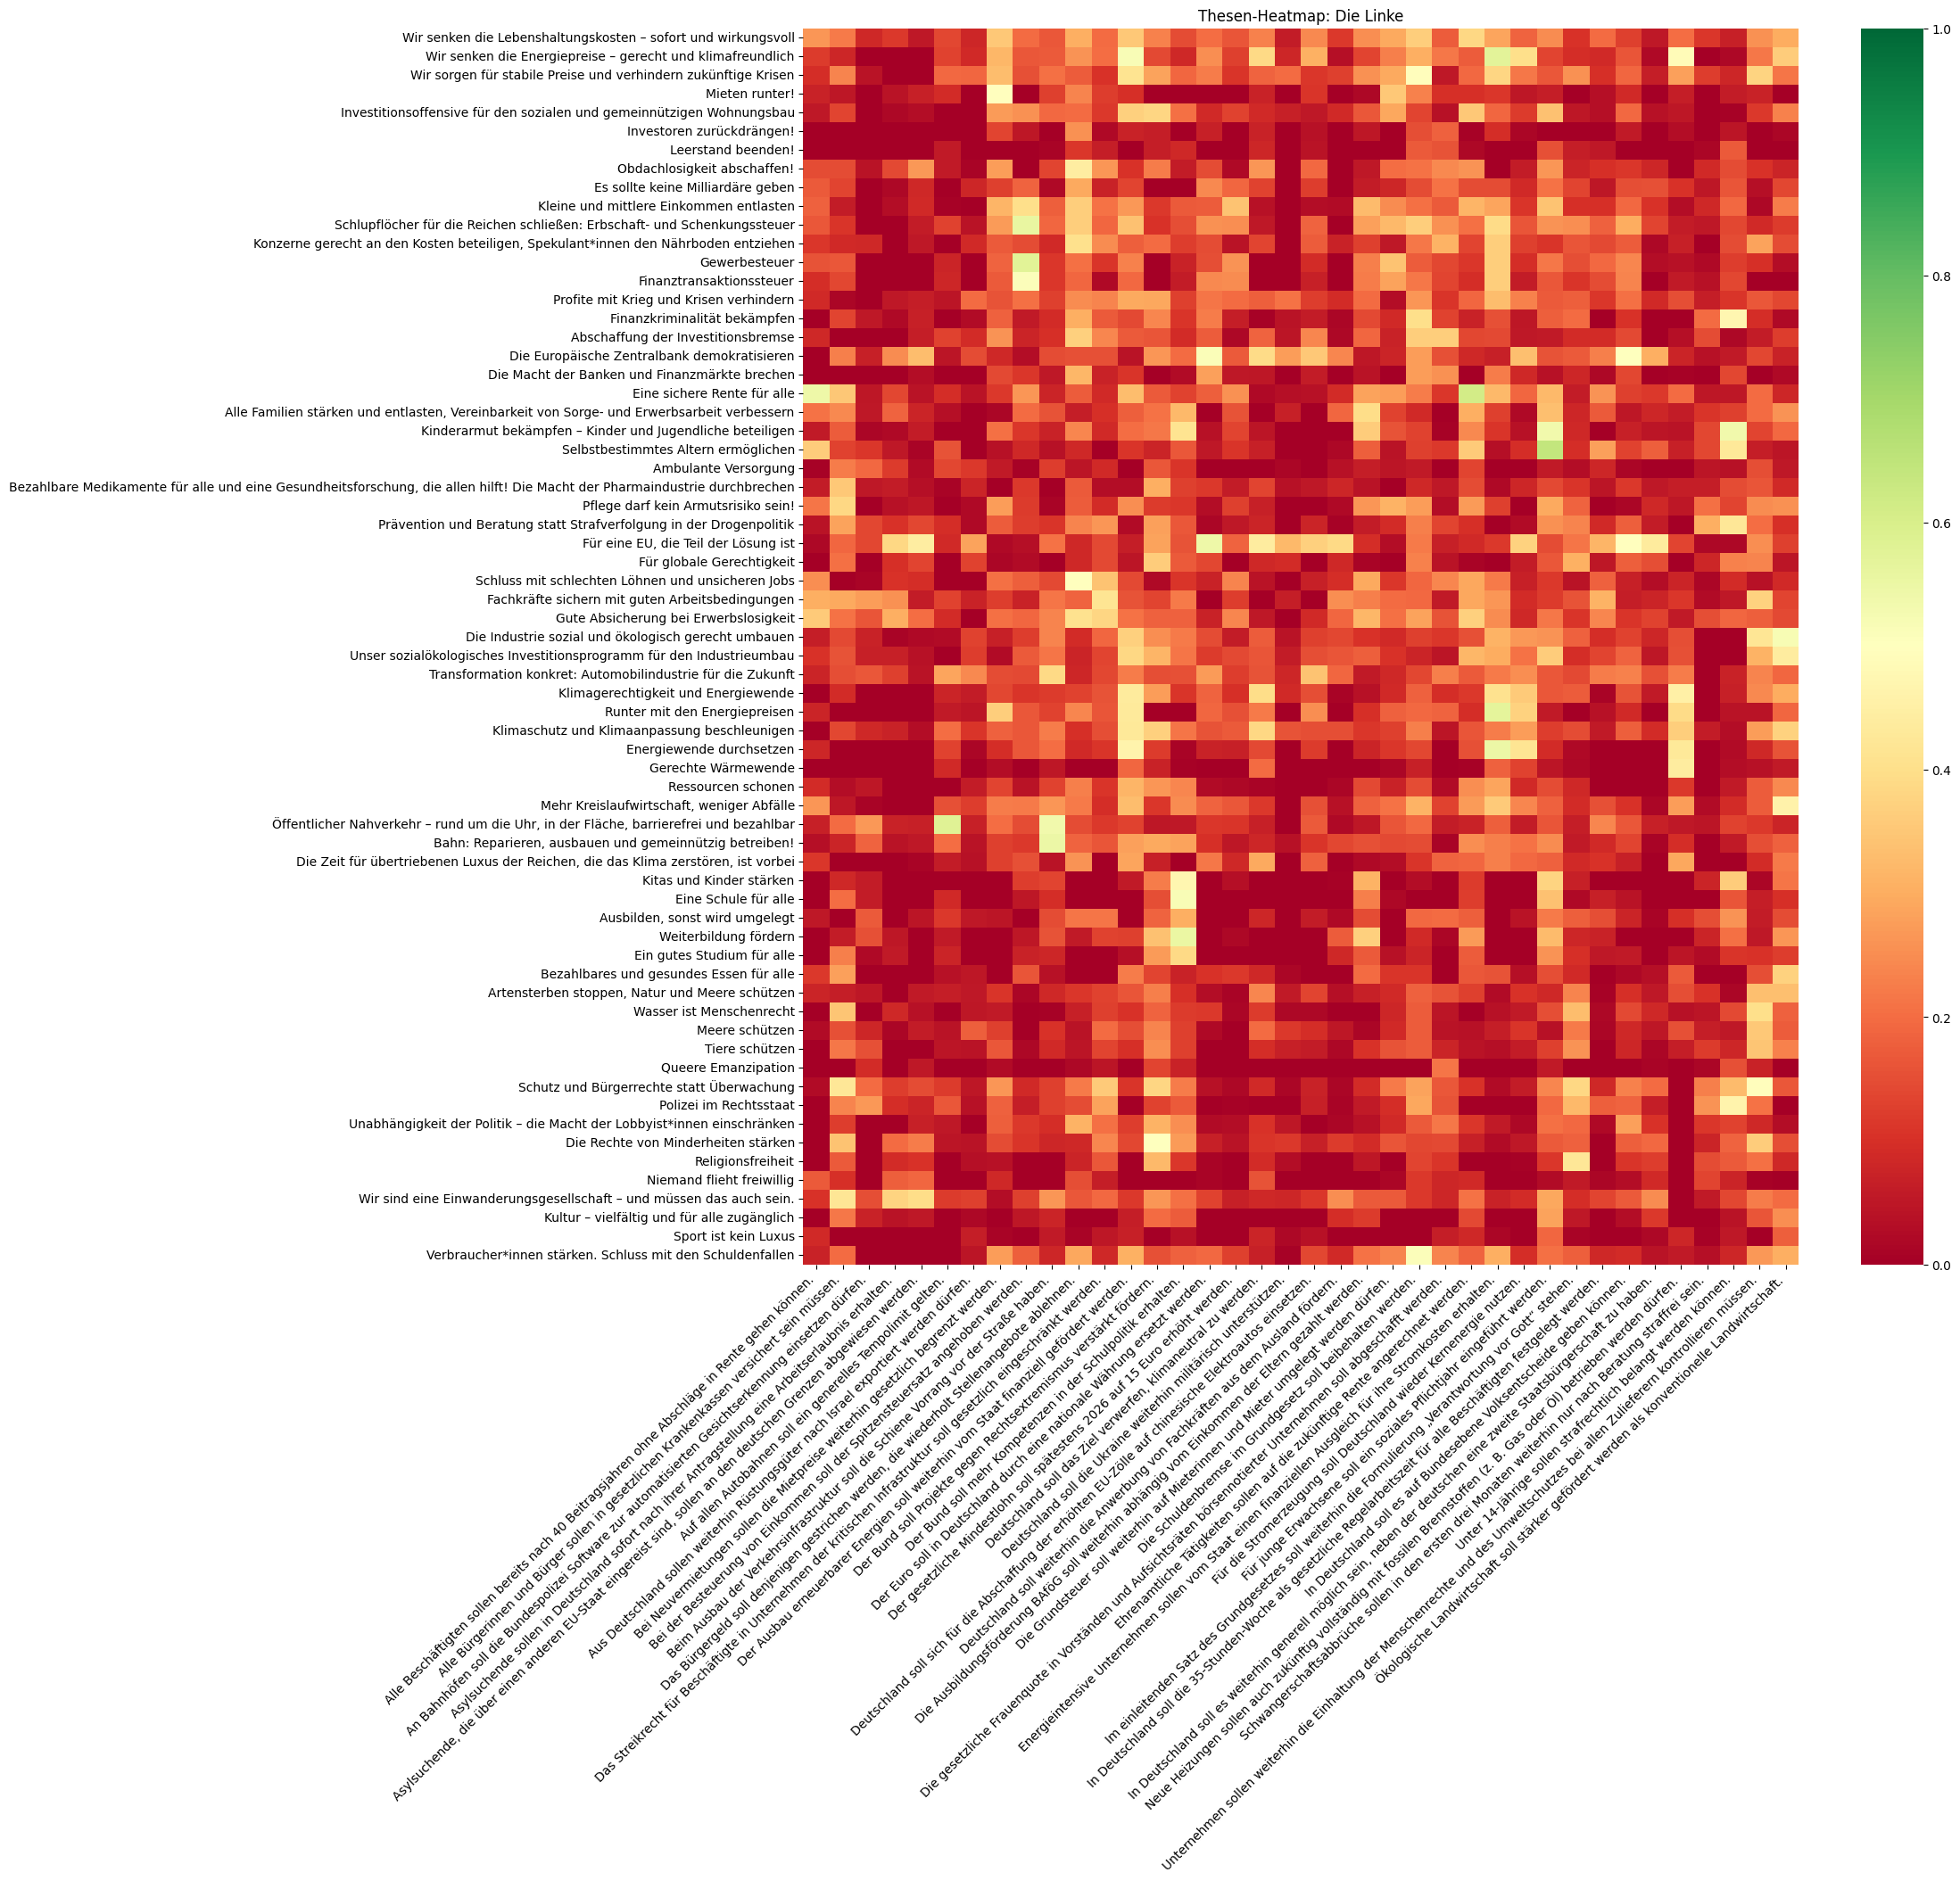

                                               These  CDU / CSU     GRÜNE  \
0  Alle Beschäftigten sollen bereits nach 40 Beit...   0.165957  0.552331   
1  Alle Bürgerinnen und Bürger sollen in gesetzli...   0.427705  0.520831   
2  An Bahnhöfen soll die Bundespolizei Software z...   0.255948  0.371790   
3  Asylsuchende sollen in Deutschland sofort nach...   0.501934  0.485888   
4  Asylsuchende, die über einen anderen EU-Staat ...   0.448501  0.521280   

        SPD       AfD  Die Linke       FDP  
0  0.527030  0.451782   0.546511  0.403819  
1  0.611033  0.551068   0.422159  0.546057  
2  0.382786  0.338926   0.274775  0.381791  
3  0.485788  0.513409   0.385631  0.529649  
4  0.450594  0.532708   0.443068  0.558654  


In [8]:


# Liste der Parteien und Thesen
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These'].tolist()
predicted_theses_dfs_dict = {}

# Schleife über die Parteien
for party_str in parties_list:
    # Filtern der Daten für die aktuelle Partei
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    
    # Entfernen von Zeilen mit NaN-Werten
    party_df = party_df.dropna()
    
    # Extrahieren der Thesen für die aktuelle Partei
    party_these_list = party_df['These'].to_list()

    # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
    similarity_df = pd.DataFrame(columns=['party_these'] + Labled_theses_list)

    # Berechnung der Ähnlichkeit für jede Partei-These
    for party_these in party_these_list:
        party_these_embedding = get_embedding(party_these)
        row = [party_these]

        # Berechnung der Kosinusähnlichkeit für jede labelte These
        for label_these in Labled_theses_list:
            label_these_embedding = get_embedding(label_these)
            similarity_score = (cosine_similarity(party_these_embedding.reshape(1, -1), label_these_embedding.reshape(1, -1))[0][0])
            row.append(similarity_score)

        similarity_df.loc[len(similarity_df)] = row

    # Visualisierung der Ähnlichkeiten als Heatmap
    plt.figure(figsize=(18, 18))
    sns.heatmap(similarity_df[Labled_theses_list],
                cmap='RdYlGn',
                annot=False,
                vmax=1,
                vmin=0,
                yticklabels=similarity_df["party_these"])
    plt.xticks(rotation=45, ha="right")1
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    # Durchschnittliche Ähnlichkeit für jede Partei
    predicted_theses_dfs_dict[party_str] = similarity_df
    predicted_theses_df[party_str] = similarity_df[Labled_theses_list].max().tolist()
    
# Ausgabe der ersten Zeilen des DataFrames mit den Vorhersagen
print(predicted_theses_df.head())


In [14]:
predicted_theses_df.head(38)

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.165957,0.552331,0.527030,0.451782,0.546511,0.403819
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.427705,0.520831,0.611033,0.551068,0.422159,0.546057
2,An Bahnhöfen soll die Bundespolizei Software z...,0.255948,0.371790,0.382786,0.338926,0.274775,0.381791
3,Asylsuchende sollen in Deutschland sofort nach...,0.501934,0.485888,0.485788,0.513409,0.385631,0.529649
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.448501,0.521280,0.450594,0.532708,0.443068,0.558654
5,Auf allen Autobahnen soll ein generelles Tempo...,0.287683,0.468257,0.434313,0.429655,0.580707,0.338651
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.433459,0.400009,0.480852,0.513655,0.281918,0.610279
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.349266,0.433342,0.669133,0.400268,0.496814,0.585142
8,Bei der Besteuerung von Einkommen soll der Spi...,0.322477,0.437894,0.462454,0.526230,0.575222,0.666587
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.469981,0.682483,0.506298,0.547893,0.548356,0.574781


In [17]:
Labled_theses_df.head(38)

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
2,An Bahnhöfen soll die Bundespolizei Software z...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu
3,Asylsuchende sollen in Deutschland sofort nach...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral
4,"Asylsuchende, die über einen anderen EU-Staat ...",stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu
5,Auf allen Autobahnen soll ein generelles Tempo...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,stimme zu,stimme zu,stimme zu,neutral,stimme nicht zu,stimme zu
7,Bei Neuvermietungen sollen die Mietpreise weit...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
8,Bei der Besteuerung von Einkommen soll der Spi...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calc_prediction_scores_func(predicted_theses_df:pd.DataFrame, label_these_num_df:pd.DataFrame)->pd.DataFrame:
    scores_df = pd.DataFrame(columns= ['score'])
    scores_df['score'] = ['RMSE', 'MAE', 'R²']
    for col in predicted_theses_df.columns[1:]: 
        predicted_values = predicted_theses_df[col]
        true_values = label_these_num_df[col]

        rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
        r2 = r2_score(true_values, predicted_values)
        mae = mean_absolute_error(true_values, predicted_values)
        scores_df[col] = [rmse, mae, r2]


    return scores_df



In [ ]:
lable_mapping_dict = {
    "stimme nicht zu": 1/6, # 0,00 - 0,33 
    "neutral": 3/6,         # 0,33 - 0,66 
    "stimme zu": 5/6        # 0,66 - 1,00
}

label_these_num_df = Labled_theses_df.copy()
for col in Labled_theses_df.columns[1:]:
    label_these_num_df[col] = Labled_theses_df[col].map(lable_mapping_dict)

del lable_mapping_dict

calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.361146,0.326441,0.313907,0.340365,0.313734,0.334620
1,MAE,0.325427,0.298759,0.287031,0.310683,0.294891,0.309931
2,R²,-0.283137,0.008657,0.018702,-0.201566,0.064927,-0.158573


In [22]:
pd.concat([predicted_theses_df['These'], predicted_theses_df.select_dtypes(include='number')-label_these_num_df.select_dtypes(include='number')], axis=1)

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,-0.000710,0.385664,0.360364,0.285116,-0.286822,0.237152
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.261038,-0.312502,-0.222300,0.384401,-0.411174,0.379390
2,An Bahnhöfen soll die Bundespolizei Software z...,-0.577385,0.205123,0.216119,-0.494408,0.108109,0.215125
3,Asylsuchende sollen in Deutschland sofort nach...,0.335268,-0.347445,-0.347545,0.346742,-0.447703,0.029649
4,"Asylsuchende, die über einen anderen EU-Staat ...",-0.384832,0.354614,0.283928,-0.300626,0.276401,-0.274679
5,Auf allen Autobahnen soll ein generelles Tempo...,0.121017,-0.365077,-0.399020,0.262988,-0.252626,0.171984
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,-0.399874,-0.433324,-0.352481,0.013655,0.115251,-0.223054
7,Bei Neuvermietungen sollen die Mietpreise weit...,-0.484068,-0.399992,-0.164201,0.233602,-0.336520,0.418475
8,Bei der Besteuerung von Einkommen soll der Spi...,0.155810,-0.395439,-0.370879,0.359564,-0.258111,0.499921
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.303315,-0.150850,-0.327036,0.381226,-0.284978,0.408114


In [23]:
Labled_theses_df

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
2,An Bahnhöfen soll die Bundespolizei Software z...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu
3,Asylsuchende sollen in Deutschland sofort nach...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral
4,"Asylsuchende, die über einen anderen EU-Staat ...",stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu
5,Auf allen Autobahnen soll ein generelles Tempo...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,stimme zu,stimme zu,stimme zu,neutral,stimme nicht zu,stimme zu
7,Bei Neuvermietungen sollen die Mietpreise weit...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
8,Bei der Besteuerung von Einkommen soll der Spi...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
